# Preparing The Keyword Spotting Dataset

## Imports:

In [1]:
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile
from tqdm import tqdm
import os
import random
import shutil
from IPython.display import Audio, display
from ipywidgets import widgets

## Load the Dataset:

I am going to use Google Speech Commands Dataset for this project since it is simpler and made for the Keyword Spotting task. It is a straight forward dataset with a few activation words in English.

- Link: https://www.tensorflow.org/datasets/catalog/speech_commands?hl=pt-br

**Other Options with more complex work needed were**:

- Fluent Speech Commands Dataset: https://fluent.ai/fluent-speech-commands-a-dataset-for-spoken-language-understanding-research/

- Mozilla Common Voice: https://commonvoice.mozilla.org/en/datasets

In [2]:
(ds_train, ds_validation, ds_test), ds_info = tfds.load('speech_commands', split=['train', 'validation', 'test'], shuffle_files=True, with_info=True, as_supervised=True,)

2025-09-18 23:20:10.498048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-18 23:20:10.506725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758248410.516096  146199 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758248410.519190  146199 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758248410.527970  146199 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
label_names = ds_info.features['label'].names
sample_rate = ds_info.features['audio'].sample_rate

In [4]:
label_names

['down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'up',
 'yes',
 '_silence_',
 '_unknown_']

In [5]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.int16, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

#### Criando um Dataset Local e Selecionando os Labels Desejados:

In [6]:
if os.path.isdir('./dataset'):
    shutil.rmtree("./dataset")


base_dir = './dataset'

splits = {
    'train': ds_train,
    'validation': ds_validation,
    'test': ds_test,
}

for split_name, ds in splits.items():
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    for label_name in label_names:
        label_dir = os.path.join(split_dir, label_name)
        os.makedirs(label_dir, exist_ok=True)
        
    counters = {label: 0 for label in label_names}

    for audio_tensor, label_tensor in tqdm(ds, desc=f"Salvando {split_name}"):
        audio_np = audio_tensor.numpy()
        label_int = label_tensor.numpy()
        label_str = label_names[label_int]
        count = counters[label_str]
        filename = f"{label_str}_{count}.wav"
        output_path = os.path.join(split_dir, label_str, filename)
        scipy.io.wavfile.write(output_path, sample_rate, audio_np)
        counters[label_str] += 1

paths = ['./dataset/train', './dataset/validation', './dataset/test']

for path in paths:
    for folder in os.listdir(path):
        if(folder == "down" or folder == "left" or folder == "up" or folder == "right" or folder == "up" or folder == "yes"):
            for file in os.listdir(os.path.join(path, folder)):
                src_path = os.path.join(path, folder, file)
                dst_dir = os.path.join(path, '_unknown_')
                os.makedirs(dst_dir, exist_ok=True)
                dst_path = os.path.join(dst_dir, file)
                os.rename(src_path, dst_path)
            os.rmdir(os.path.join(path, folder))

Salvando test: 100%|██████████| 4890/4890 [00:00<00:00, 6153.12it/s]


## Exploring the Dataset:

#### Verifying the Dataset:

In [7]:
base_dir = 'dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



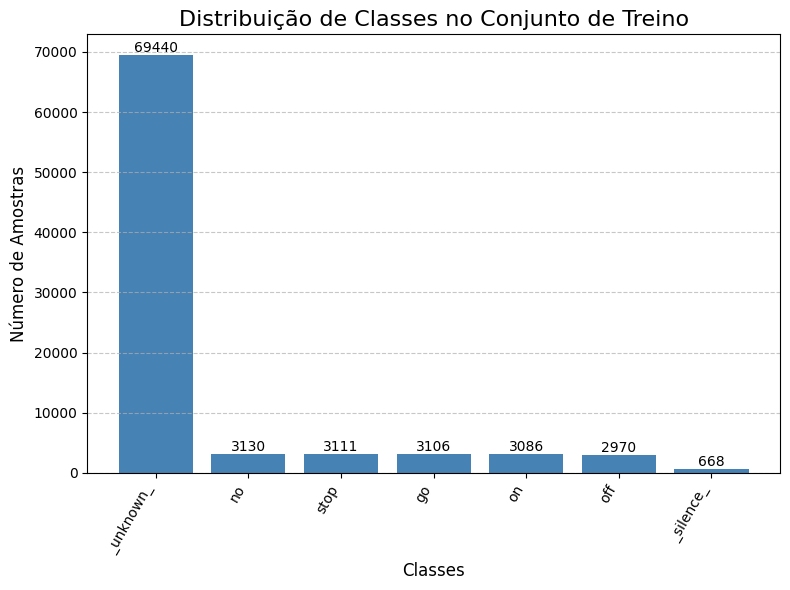

In [8]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[0], result_counts[0], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Treino', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

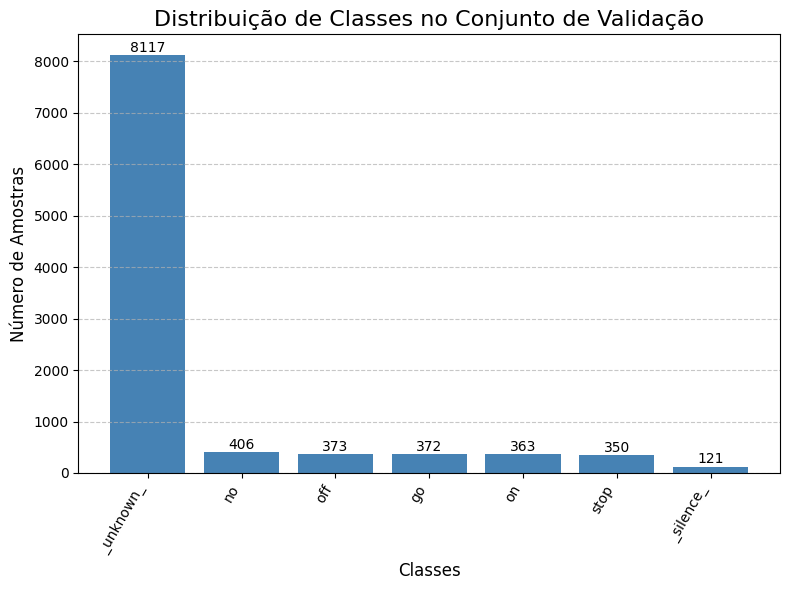

In [9]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[1], result_counts[1], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Validação', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

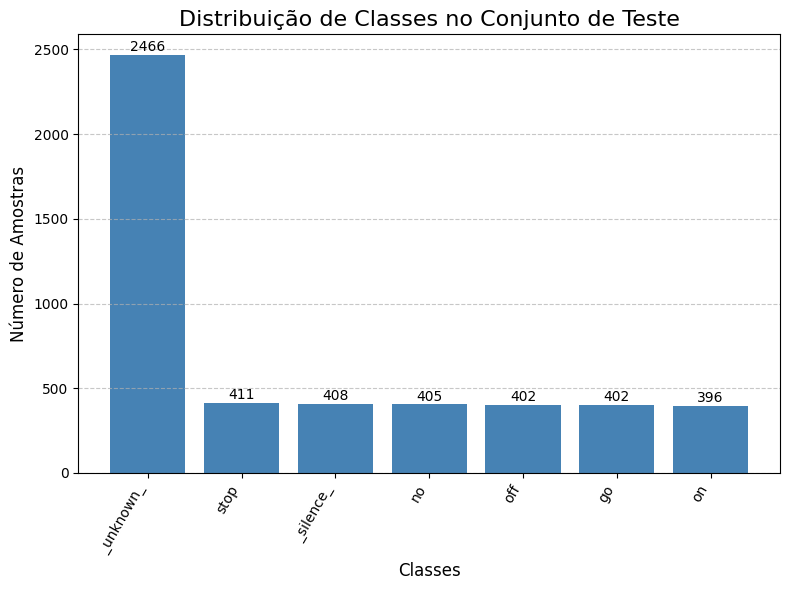

In [10]:
plt.figure(figsize=(8,6))
    
bars = plt.bar(result_labels[2], result_counts[2], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Teste', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Data Augmentation:

In [ ]:
# to do

## Data Removal:

In [11]:
def del_samples(path, quant):
    all_files = os.listdir(path)
    for _ in tqdm(range(0, quant), desc=f"Deletando de {path}"):
        del_arq = random.choice(all_files)
        all_files.remove(del_arq)
        os.remove(os.path.join(path, del_arq))

In [12]:
del_samples("./dataset/train/_unknown_", 66310)

del_samples("./dataset/validation/_unknown_", 7711)

del_samples("./dataset/test/_unknown_", 2000)

Deletando de ./dataset/test/_unknown_: 100%|██████████| 2000/2000 [00:00<00:00, 42732.74it/s]


In [13]:
base_dir = 'dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



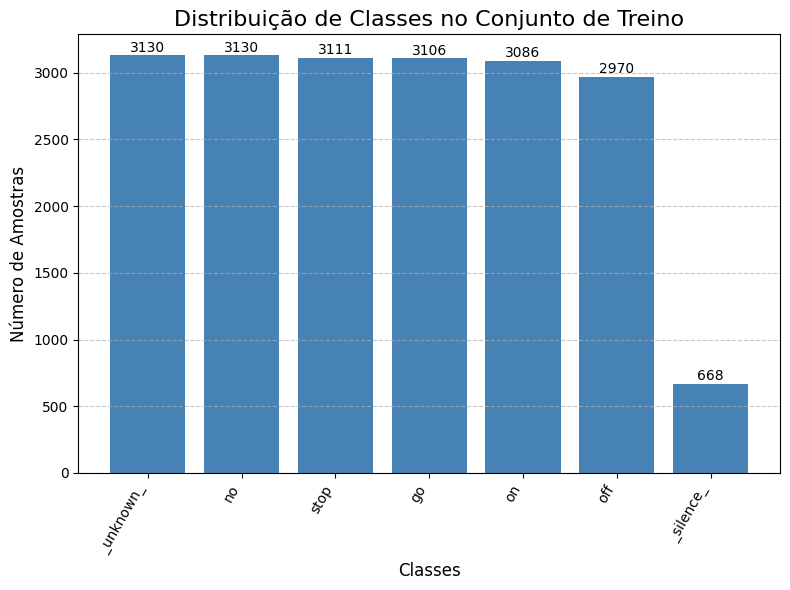

In [14]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[0], result_counts[0], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Treino', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

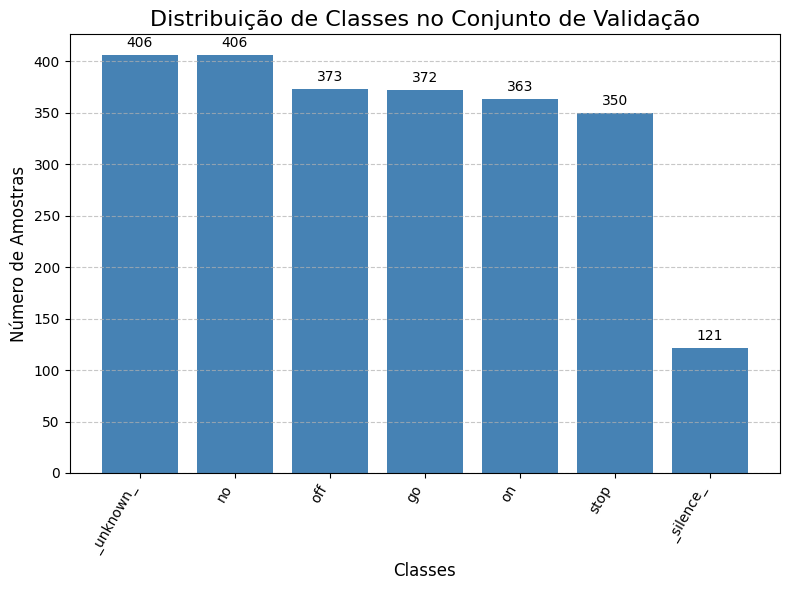

In [15]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[1], result_counts[1], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Validação', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

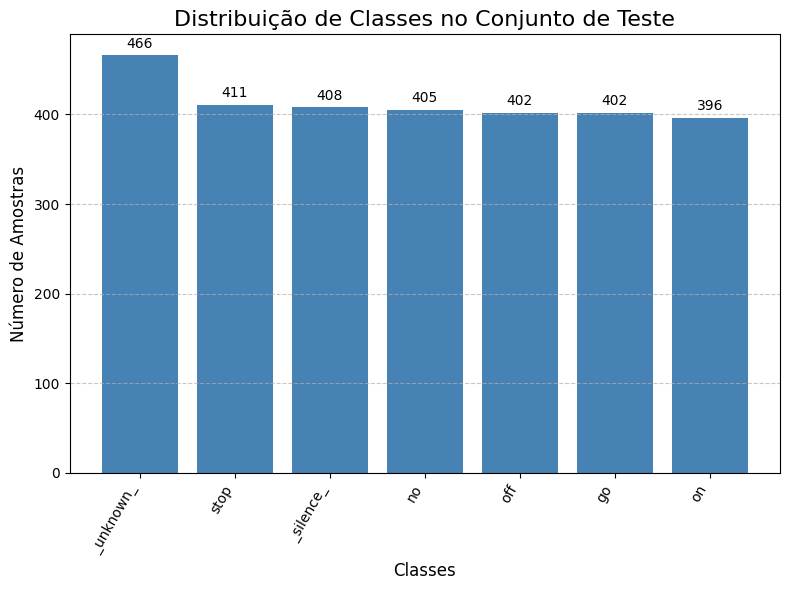

In [16]:
plt.figure(figsize=(8,6))
    
bars = plt.bar(result_labels[2], result_counts[2], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Teste', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

## Visualizing Samples:

In [17]:
def plotar_exemplos_integrado(base_path: str, exemplos_por_classe: int = 5):
    try:
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    except FileNotFoundError:
        print(f"Erro: O diretório '{base_path}' não foi encontrado.")
        return

    # Lista principal que vai conter as linhas (HBox) de cada classe
    linhas_de_widgets = []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        
        try:
            wav_files = [f for f in os.listdir(class_path) if f.lower().endswith('.wav')]
            if not wav_files:
                continue

            num_a_selecionar = min(exemplos_por_classe, len(wav_files))
            arquivos_selecionados = random.sample(wav_files, num_a_selecionar)

            # Lista para os "cards" (widgets.Output) desta classe
            blocos_para_linha_atual = []
            
            # Adiciona um rótulo no início da linha para identificar a classe
            label_classe = widgets.Label(
                value=f"{class_name}:",
                layout=widgets.Layout(display='flex', align_items='center', width='80px') # Layout para alinhar verticalmente
            )
            blocos_para_linha_atual.append(label_classe)

            for file_name in arquivos_selecionados:
                file_path = os.path.join(class_path, file_name)
                
                # Cria o widget de "card" individual
                card = widgets.Output(layout={'border': '1px solid black', 'padding': '5px', 'width': '180px'})
                
                with card:
                    try:
                        # Carrega o áudio
                        sr, audio = scipy.io.wavfile.read(file_path)
                        if audio.ndim > 1:
                            audio = audio[:, 0]

                        # --- Geração do Gráfico em Memória ---
                        # Cria uma figura pequena, específica para este card
                        fig, ax = plt.subplots(figsize=(3, 2), dpi=75)
                        ax.plot(audio, color='dodgerblue')
                        ax.axis('off') # Remove eixos para um visual limpo
                        plt.tight_layout()
                        
                        # Exibe a figura e a fecha para não poluir a memória
                        plt.show(fig)
                        plt.close(fig)

                        # Exibe o player de áudio
                        display(Audio(data=audio, rate=sr))
                    
                    except Exception as e:
                        print(f"Erro: {e}")

                blocos_para_linha_atual.append(card)

            # Agrupa todos os cards da classe em uma linha horizontal
            linha = widgets.HBox(blocos_para_linha_atual)
            linhas_de_widgets.append(linha)
        
        except FileNotFoundError:
            continue

    # Exibe todas as linhas empilhadas verticalmente
    display(widgets.VBox(linhas_de_widgets))

In [18]:
plotar_exemplos_integrado("dataset/train")